In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/sample_submission.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/train.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/test.csv


Importing libraries...
Loading data...
Original train shape: (10000, 9)
Original test shape: (3320, 8)
Combined data shape: (13320, 7)

--- Rubric 4: Handling Duplicates ---
Duplicates found in training data: 0
Dropped 0 duplicates. New combined shape: (13320, 7)

--- Rubric 3: Handling Missing Values (Strings & Simple Numerics) ---
Missing values BEFORE imputation:
balcony       609
bath           73
total_sqft     46
size           16
location        1
dtype: int64

Missing values AFTER simple imputation:
total_sqft      46
area_type        0
availability     0
location         0
size             0
dtype: int64

--- Feature Engineering & Data Cleaning ---

--- Rubric 3: Handling Missing Values (Post-Cleaning) ---
Missing 'total_sqft' values: 46
Filled missing 'total_sqft' with median.

--- Rubric 7: Encoding Categorical Features ---
Original unique locations: 1305
Reduced unique locations: 242
Data shape after one-hot encoding: (13320, 249)


--- Rubric 1: Final Data Types ---
<class

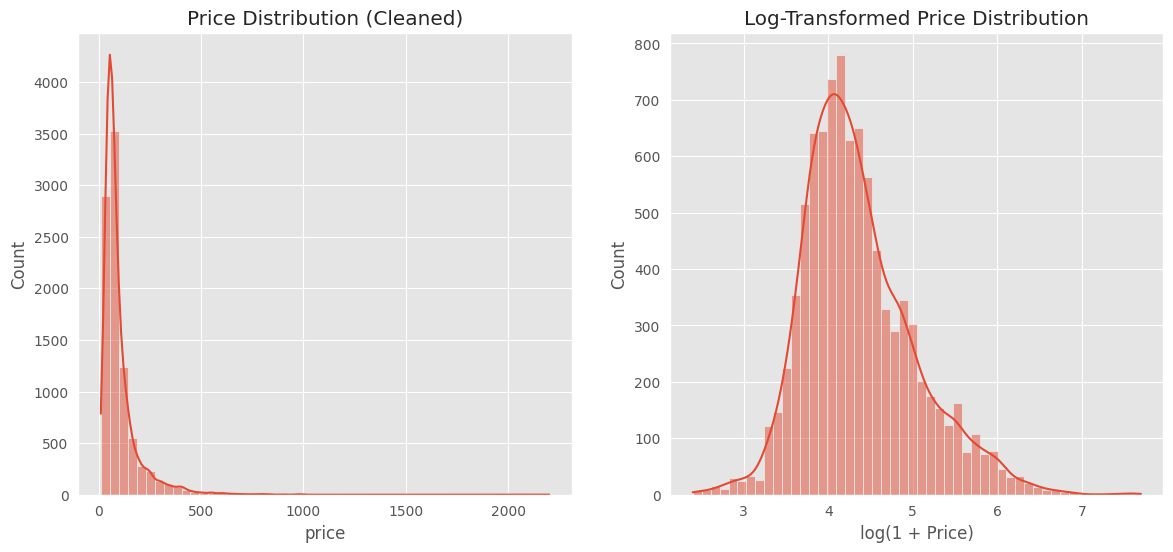

Insight 1: The target variable 'price' is heavily right-skewed. Applying a log-transform (log1p) makes it much closer to a normal distribution, which is ideal for most regression models.


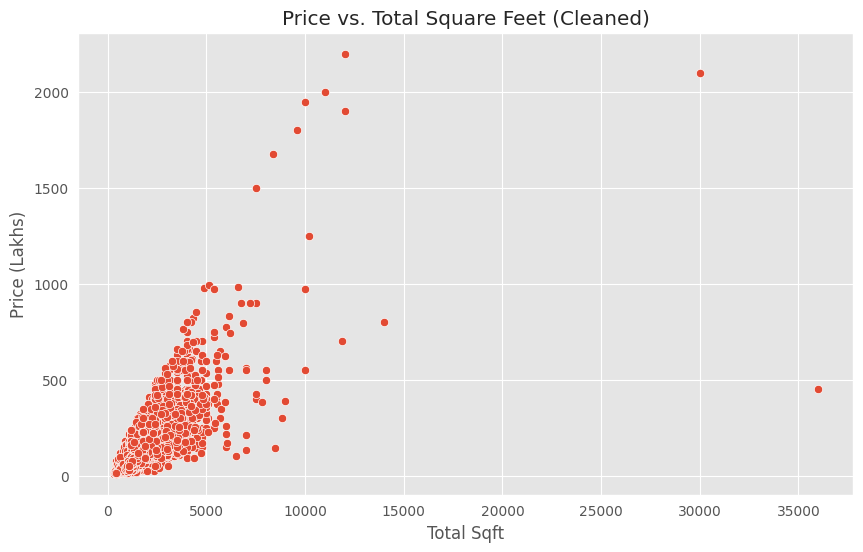

Insight 2: There is a clear positive correlation between total_sqft and price. After cleaning, the relationship is much more linear and less scattered by extreme outliers.


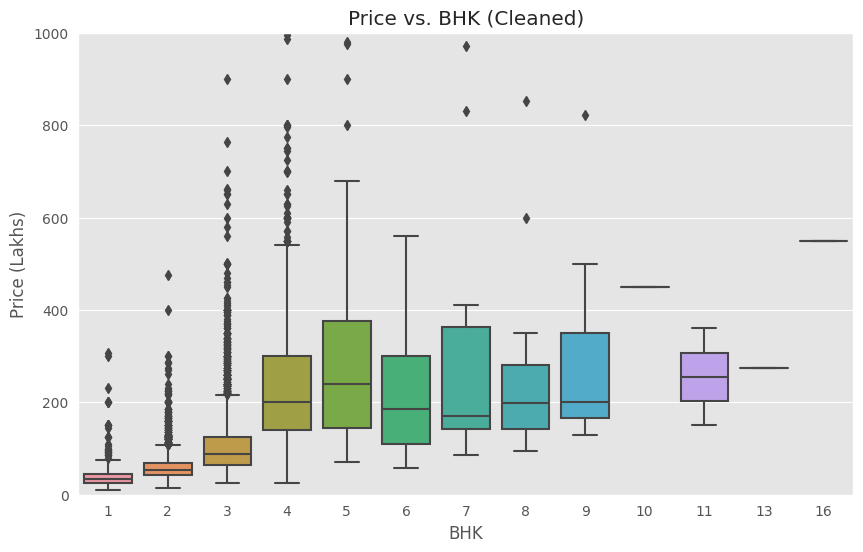

Insight 3: Price generally increases with the number of bedrooms (BHK). We can see some spread, but the illogical outliers (e.g., 10 BHK with a very low price) have been removed.

--- Final Data Preparation for Modeling ---
Final training data shape: (9194, 249)
Final test data shape: (3320, 249)

--- Rubric 7: Scaling Numerical Features ---
Numerical features scaled.
   availability  total_sqft      bath   balcony       bhk  \
0      0.523052   -0.533432 -0.515179  0.498952  0.396145   
1      0.523052   -0.347442 -0.515179 -0.763393 -0.656198   
2     -1.911855   -0.006460  0.499724  0.498952  0.396145   
3      0.523052    0.293191  1.514628  0.498952  0.396145   
4      0.523052   -0.279245 -0.515179 -2.025739  0.396145   

   location_1st Block Jayanagar  location_1st Phase JP Nagar  \
0                         False                        False   
1                         False                        False   
2                         False                        False   
3     

In [2]:
# --- Initial Setup: Import All Necessary Libraries ---
print("Importing libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_squared_error

# Settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.style.use('ggplot')

# --- 1. Load Data ---
print("Loading data...")
try:
    train_df = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/train.csv')
    test_df = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/test.csv')
except FileNotFoundError:
    print("Ensure 'train[1].csv' and 'test[1].csv' are uploaded to the notebook environment.")
    # In a real notebook, you'd stop here.
    
print(f"Original train shape: {train_df.shape}")
print(f"Original test shape: {test_df.shape}")

# Store test IDs for final submission
test_ids = test_df['id']

# Separate target variable
y_train_full = train_df['price'].copy()

# Combine train and test for consistent preprocessing
# Drop 'price' from train and 'id' from both
X = train_df.drop(['id', 'price'], axis=1)
X_test = test_df.drop('id', axis=1)
all_data = pd.concat([X, X_test], axis=0).reset_index(drop=True)

print(f"Combined data shape: {all_data.shape}")

# --- Rubric 4: Identify and Handle Duplicates ---
# We do this on the training data *before* combination
print("\n--- Rubric 4: Handling Duplicates ---")
duplicate_count = train_df.duplicated().sum()
print(f"Duplicates found in training data: {duplicate_count}")
# Re-load and drop duplicates from train_df before re-combining
train_df = train_df.drop_duplicates()
y_train_full = train_df['price'].copy()
X = train_df.drop(['id', 'price'], axis=1)
X_test = test_df.drop('id', axis=1)
all_data = pd.concat([X, X_test], axis=0).reset_index(drop=True)
print(f"Dropped {duplicate_count} duplicates. New combined shape: {all_data.shape}")


# --- Rubric 3: Identify and Handle Missing Values (Initial Pass) ---
print("\n--- Rubric 3: Handling Missing Values (Strings & Simple Numerics) ---")
# Check missing values
print("Missing values BEFORE imputation:")
print(all_data.isnull().sum().sort_values(ascending=False).head())

# Fill missing categorical/simple numerical data
# Using mode for these as they are categorical or discrete
all_data['location'].fillna(all_data['location'].mode()[0], inplace=True)
all_data['size'].fillna(all_data['size'].mode()[0], inplace=True)
all_data['bath'].fillna(all_data['bath'].median(), inplace=True)
all_data['balcony'].fillna(all_data['balcony'].mode()[0], inplace=True)

print("\nMissing values AFTER simple imputation:")
print(all_data.isnull().sum().sort_values(ascending=False).head())

# --- Feature Engineering & Cleaning ---
print("\n--- Feature Engineering & Data Cleaning ---")

# 1. Clean 'size' -> 'bhk'
# 'size' column has '2 BHK', '3 Bedroom', etc. We just want the number.
all_data['bhk'] = all_data['size'].apply(lambda x: int(x.split(' ')[0]))

# 2. Clean 'total_sqft'
# This column has ranges (e.g., '1133 - 1384') and other values.
def convert_sqft_to_num(x):
    if isinstance(x, (int, float)):
        return x
    if '-' in x:
        parts = x.split('-')
        if len(parts) == 2:
            try:
                return (float(parts[0].strip()) + float(parts[1].strip())) / 2
            except:
                return np.nan
    try:
        # Handle cases like '34.46Sq. Meter'
        if 'Sq. Meter' in x:
            return float(x.split('Sq. Meter')[0].strip()) * 10.7639
        # Handle cases like '3Cents'
        if 'Cents' in x:
            return float(x.split('Cents')[0].strip()) * 435.6
        # Handle cases like '1.25Acres'
        if 'Acres' in x:
            return float(x.split('Acres')[0].strip()) * 43560
        # Handle cases like '1100Sq. Yards'
        if 'Sq. Yards' in x:
            return float(x.split('Sq. Yards')[0].strip()) * 9
        return float(x)
    except:
        return np.nan

all_data['total_sqft'] = all_data['total_sqft'].apply(convert_sqft_to_num)

# 3. Handle 'availability'
all_data['availability'] = all_data['availability'].apply(lambda x: 1 if x == 'Ready To Move' else 0)

# --- Rubric 3: Handle Missing Values (Second Pass) ---
# Now we fill NaNs created by cleaning 'total_sqft'
print("\n--- Rubric 3: Handling Missing Values (Post-Cleaning) ---")
print(f"Missing 'total_sqft' values: {all_data['total_sqft'].isnull().sum()}")
all_data['total_sqft'].fillna(all_data['total_sqft'].median(), inplace=True)
print("Filled missing 'total_sqft' with median.")

# --- Rubric 7: Encode Categorical Features (Location) ---
# 'location' has too many unique values (high cardinality).
# We'll group rare locations into an 'other' category.
print("\n--- Rubric 7: Encoding Categorical Features ---")
print(f"Original unique locations: {all_data['location'].nunique()}")

location_stats = all_data['location'].value_counts()
locations_less_than_10 = location_stats[location_stats <= 10].index

all_data['location'] = all_data['location'].apply(lambda x: 'other' if x in locations_less_than_10 else x)
print(f"Reduced unique locations: {all_data['location'].nunique()}")

# Drop the original 'size' column as we have 'bhk'
all_data = all_data.drop('size', axis=1)

# One-Hot Encode 'location' and 'area_type'
all_data = pd.get_dummies(all_data, columns=['location', 'area_type'], drop_first=True)
print(f"Data shape after one-hot encoding: {all_data.shape}")


# --- Rubric 1: Identify Data Types ---
print("\n\n--- Rubric 1: Final Data Types ---")
print(all_data.info())

# --- Rubric 2: Descriptive Statistics ---
print("\n--- Rubric 2: Descriptive Statistics (Numerical) ---")
print(all_data[['total_sqft', 'bath', 'balcony', 'bhk', 'availability']].describe().T)

# --- Rubric 5: Identify and Handle Outliers ---
# We will do this by removing illogical data points from the TRAINING set.
# First, split the data back into train and test
print("\n--- Rubric 5: Identifying and Handling Outliers ---")

X_processed = all_data.iloc[:len(y_train_full)]
X_test_processed = all_data.iloc[len(y_train_full):]

# Create a temporary dataframe with price for outlier removal
train_temp = X_processed.copy()
train_temp['price'] = y_train_full

# 1. Create price_per_sqft
train_temp['price_per_sqft'] = (train_temp['price'] * 100000) / train_temp['total_sqft']

# 2. Remove outliers based on price_per_sqft (e.g., < 1000 or > 20000)
original_rows = train_temp.shape[0]
train_cleaned = train_temp[
    (train_temp['price_per_sqft'] >= 1000) & 
    (train_temp['price_per_sqft'] <= 20000)
]
print(f"Removed {original_rows - train_cleaned.shape[0]} rows based on extreme price_per_sqft.")

# 3. Remove outliers based on sqft per bhk
original_rows = train_cleaned.shape[0]
train_cleaned = train_cleaned[
    (train_cleaned['total_sqft'] / train_cleaned['bhk']) >= 300
]
print(f"Removed {original_rows - train_cleaned.shape[0]} rows with < 300 sqft per bhk.")

# 4. Remove outliers where bathrooms > bhk + 2
original_rows = train_cleaned.shape[0]
train_cleaned = train_cleaned[
    train_cleaned['bath'] < (train_cleaned['bhk'] + 2)
]
print(f"Removed {original_rows - train_cleaned.shape[0]} rows with illogical bathroom counts.")

# --- Rubric 6: Visualizations (on Cleaned Data) ---
print("\n--- Rubric 6: Visualizations ---")

# 1. Target Variable Distribution (Original Price)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(train_cleaned['price'], kde=True, bins=50)
plt.title('Price Distribution (Cleaned)')
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train_cleaned['price']), kde=True, bins=50)
plt.title('Log-Transformed Price Distribution')
plt.xlabel('log(1 + Price)')
plt.show()
print("Insight 1: The target variable 'price' is heavily right-skewed. Applying a log-transform (log1p) makes it much closer to a normal distribution, which is ideal for most regression models.")

# 2. total_sqft vs. price
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_cleaned['total_sqft'], y=train_cleaned['price'])
plt.title('Price vs. Total Square Feet (Cleaned)')
plt.xlabel('Total Sqft')
plt.ylabel('Price (Lakhs)')
plt.show()
print("Insight 2: There is a clear positive correlation between total_sqft and price. After cleaning, the relationship is much more linear and less scattered by extreme outliers.")

# 3. bhk vs. price
plt.figure(figsize=(10, 6))
sns.boxplot(x=train_cleaned['bhk'], y=train_cleaned['price'])
plt.title('Price vs. BHK (Cleaned)')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')
plt.ylim(0, 1000) # Limit y-axis for better readability
plt.show()
print("Insight 3: Price generally increases with the number of bedrooms (BHK). We can see some spread, but the illogical outliers (e.g., 10 BHK with a very low price) have been removed.")

# --- Final Data Preparation ---
print("\n--- Final Data Preparation for Modeling ---")

# Create final X and y
# We drop price and price_per_sqft from our training data
X_final = train_cleaned.drop(['price', 'price_per_sqft'], axis=1)
# We log-transform the target variable
y_final = np.log1p(train_cleaned['price'])

# Ensure test set columns match
# Align drops any columns in one that aren't in the other
X_final, X_test_final = X_final.align(X_test_processed, join='inner', axis=1, fill_value=0)

print(f"Final training data shape: {X_final.shape}")
print(f"Final test data shape: {X_test_final.shape}")


# --- Rubric 7: Scale Numerical Features ---
print("\n--- Rubric 7: Scaling Numerical Features ---")

# Identify numerical columns to scale (non-dummy columns)
numerical_cols = ['total_sqft', 'bath', 'balcony', 'bhk', 'availability']
# Filter list to only include columns present in X_final
numerical_cols = [col for col in numerical_cols if col in X_final.columns]

scaler = StandardScaler()
X_final[numerical_cols] = scaler.fit_transform(X_final[numerical_cols])
X_test_final[numerical_cols] = scaler.transform(X_test_final[numerical_cols])

print("Numerical features scaled.")
print(X_final.head())

# --- Rubric 8: Model Building (at least 7) ---
print("\n--- Rubric 8: Model Building (Baseline) ---")

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.001, random_state=42),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.8, random_state=42),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Evaluate models using 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
model_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_final, y_final, 
                             cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)
    # Scores are -MSE, so we take sqrt of negative scores to get RMSE
    rmse_scores = np.sqrt(-scores)
    model_results[name] = rmse_scores.mean()
    print(f"{name} | RMSE: {rmse_scores.mean():.6f} (std: {rmse_scores.std():.6f})")

# --- Rubric 10: Comparison of Model Performances (Baseline) ---
print("\n--- Rubric 10: Baseline Model Performance Comparison ---")
baseline_results_df = pd.DataFrame.from_dict(model_results, orient='index', columns=['RMSE'])
print(baseline_results_df.sort_values(by='RMSE'))

# --- Rubric 9: Hyperparameter Tuning (on 3 models) ---
print("\n--- Rubric 9: Hyperparameter Tuning ---")
# We'll tune Lasso, Random Forest, and XGBoost

# 1. Tune Lasso
print("Tuning Lasso...")
lasso_params = {'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01]}
grid_lasso = GridSearchCV(Lasso(random_state=42), lasso_params, cv=kfold,
                          scoring='neg_mean_squared_error', n_jobs=-1)
grid_lasso.fit(X_final, y_final)
lasso_best_score = np.sqrt(-grid_lasso.best_score_)
print(f"Best Lasso RMSE: {lasso_best_score:.6f}")
print(f"Best Lasso Params: {grid_lasso.best_params_}")

# 2. Tune Random Forest (Small grid for speed)
print("\nTuning Random Forest...")
rf_params = {
    'n_estimators': [200],
    'max_depth': [15, 20],
    'min_samples_leaf': [1, 3]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_params, cv=kfold,
                       scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_final, y_final)
rf_best_score = np.sqrt(-grid_rf.best_score_)
print(f"Best RF RMSE: {rf_best_score:.6f}")
print(f"Best RF Params: {grid_rf.best_params_}")

# 3. Tune XGBoost (Small grid for speed)
print("\nTuning XGBoost...")
xgb_params = {
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5],
    'subsample': [0.7, 1.0]
}
grid_xgb = GridSearchCV(XGBRegressor(random_state=42, n_jobs=-1), xgb_params, cv=kfold,
                        scoring='neg_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_final, y_final)
xgb_best_score = np.sqrt(-grid_xgb.best_score_)
print(f"Best XGB RMSE: {xgb_best_score:.6f}")
print(f"Best XGB Params: {grid_xgb.best_params_}")

# --- Rubric 10: Comparison of Model Performances (Final) ---
print("\n\n--- Rubric 10: Final Model Comparison ---")
tuned_scores = {
    "Tuned Lasso": lasso_best_score,
    "Tuned Random Forest": rf_best_score,
    "Tuned XGBoost": xgb_best_score
}
tuned_results_df = pd.DataFrame.from_dict(tuned_scores, orient='index', columns=['RMSE'])

final_comparison = pd.concat([baseline_results_df, tuned_results_df])
print(final_comparison.sort_values(by='RMSE'))

# --- Final Prediction and Submission ---
print("\n--- Creating Final Submission File ---")

# Choose the best model (e.g., the tuned XGBoost)
best_model = grid_xgb.best_estimator_

# Retrain the best model on ALL cleaned training data
best_model.fit(X_final, y_final)

# Make predictions on the final test set
log_predictions = best_model.predict(X_test_final)

# Inverse-transform the predictions (from log(1+p) back to p)
final_predictions = np.expm1(log_predictions)

# Ensure no negative prices
final_predictions[final_predictions < 0] = 0

# --- MODIFIED SUBMISSION BLOCK ---
# Load the sample submission file from the provided path
try:
    # Use the path you provided
    submission_df = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/sample_submission.csv')
    
    # Check if 'price' column exists
    if 'price' in submission_df.columns:
        target_column = 'price'
    else:
        # If 'price' isn't the column, find the column that is NOT 'id'
        target_column = [col for col in submission_df.columns if col != 'id'][0]
        print(f"Target column in sample_submission.csv identified as: {target_column}")

    # Assign the predictions to the target column
    # Ensure the length matches
    if len(final_predictions) == len(submission_df):
        submission_df[target_column] = final_predictions
        
        # Save to CSV
        submission_df.to_csv('submission.csv', index=False)
        print("Done!!!!!!")
        print(submission_df.head())
    else:
        # This is a safety check in case preprocessing resulted in mismatched rows
        print(f"Error: Prediction length ({len(final_predictions)}) does not match sample submission length ({len(submission_df)}).")
        print("Please check data. Creating submission_df manually as a fallback.")
        submission_df_manual = pd.DataFrame({
            'id': test_ids,
            'price': final_predictions
        })
        submission_df_manual.to_csv('submission.csv', index=False)
        print("Done (manual fallback)!!!!!!")
        print(submission_df_manual.head())

except FileNotFoundError:
    print("Error: Sample submission file not found at the specified path.")
    print("Falling back to creating submission.csv manually from test_ids.")
    # Fallback to original method if file not found
    submission_df = pd.DataFrame({
        'id': test_ids,
        'price': final_predictions
    })
    # Save to CSV
    submission_df.to_csv('submission.csv', index=False)
    print("Done (manual fallback)!!!!!!")
    print(submission_df.head())

